# Modern Wage Dynamics 
ASU Math+ ABM Spring School 2024 

J M Applegate, Jieshu Wang, Sola Kim
March 5, 2024 
With price and wage set according to hours, and useable money and inventory.

Modification: Add AI

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

#### import functions from model files
from series_parameters_1 import series_params
from initialisation_functions_1 import *

from firm_functions_1 import *

from household_functions_1 import *
from market_functions_1 import *
from simulation_1 import *
from numpy.random import default_rng
from operator import itemgetter

import warnings
warnings.filterwarnings('ignore')

plt.rc('font',**{'family':'sans-serif','sans-serif':['Futura']})

## Original Model

Without AI

In [2]:
params = {'fix_ai_cost_list':(1_000_000,), 'ai_omega_list':(50,), 'ai_tax_rate_list':(1,)}
srf, final_srf=run_simulation(**params)

This experiment consists of 100 simulations
consisting of 1 parameter sets.

Finished series.


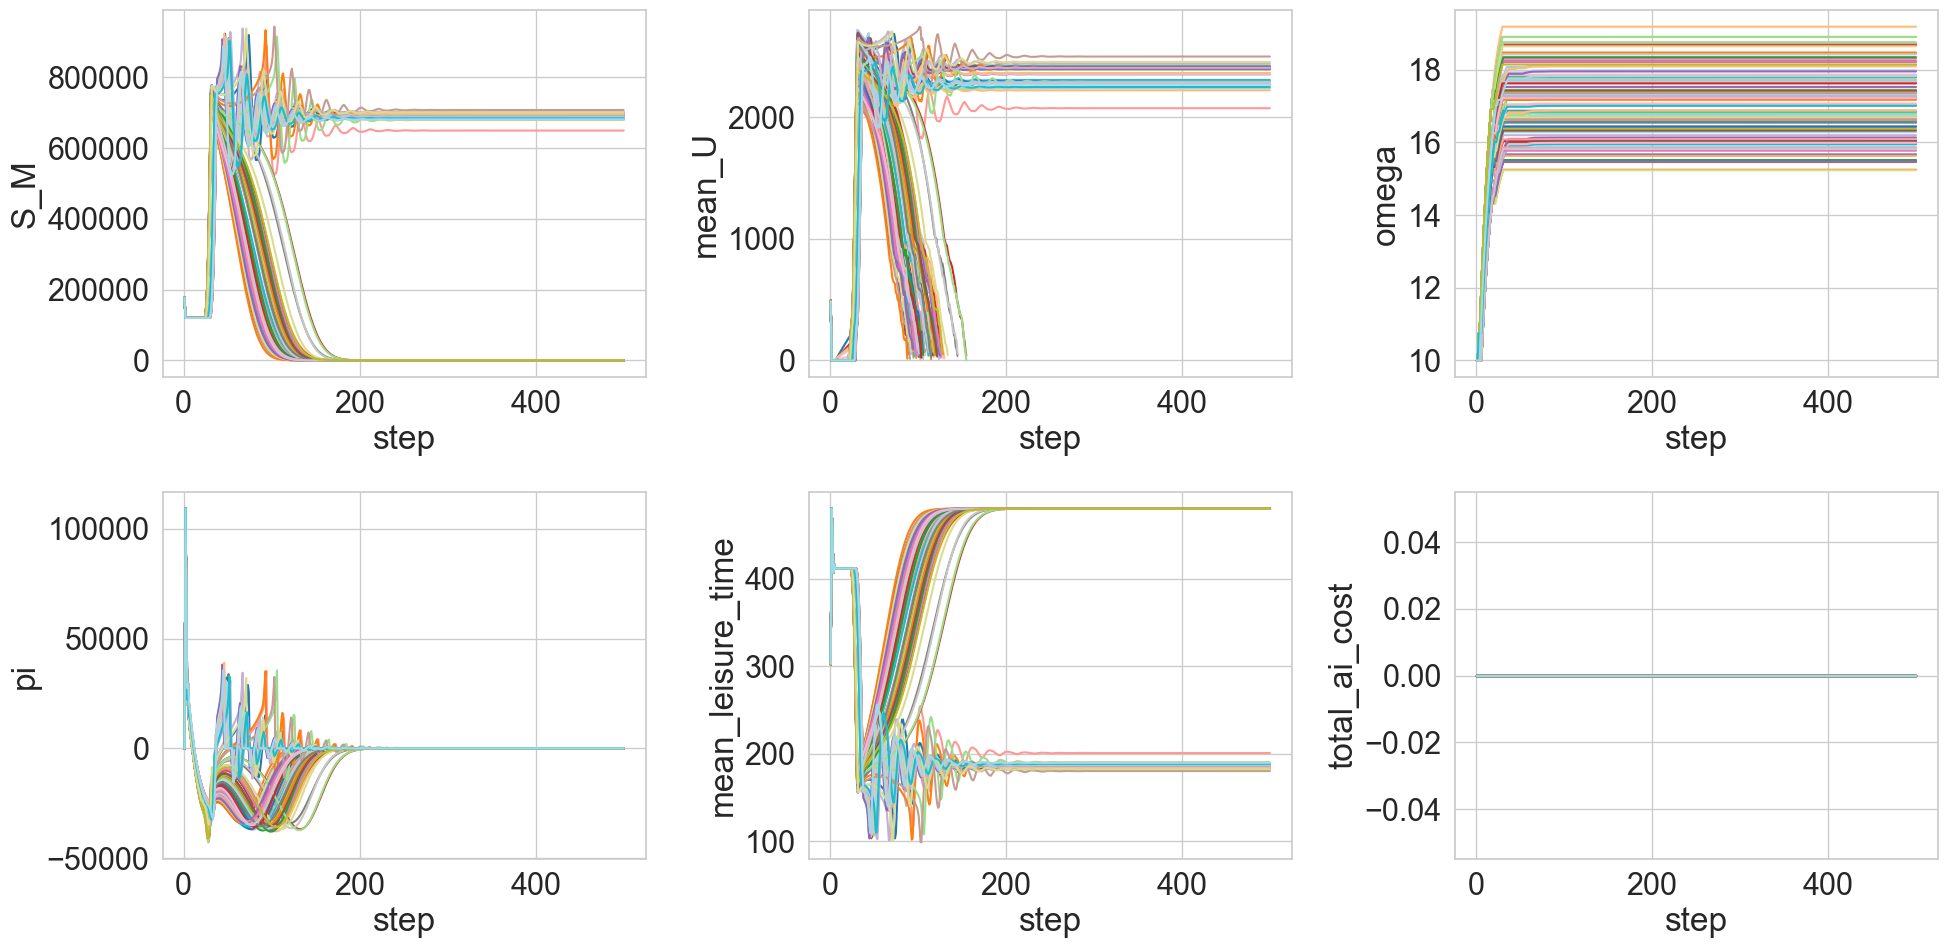

In [3]:

sns.set_theme(style='whitegrid', font_scale=2)

fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(20,10), sharey=False, sharex=False,tight_layout=True)

for col, ax in zip(['S_M','mean_U','omega','pi','mean_leisure_time','total_ai_cost'], axes.flat):
    sns.lineplot(data=srf.query("(step > 0) & (theta == 0.1)"), x='step', y=col, hue='run',
             ax=ax, legend=False, palette='tab20')

## Wage model considering AI/automation

Three variables added:
- __ai_fix_cost__: Fixed cost per period if AI is used to produce sugar
- __ai_omega__: Variable cost per human-equivalent-hour if AI is used to produce sugar
- __ai_tax_rate__: Tax per quantity of sugar if AI is used to produce the sugar

Functions added:
- __determine_is_ai__: The firm decide whether AI or human labor is used in this period based on the anticipated profit.

Funcstions modified:
- __profit__: added the scenario where AI is used, in which case, profit equals revenue minus cost and tax.
- __plan_consumption__: added AI subsidy (or basic income redistributed from the government by collecting AI tax)  



In [28]:
params = {'fix_ai_cost_list':(200_000,), 'ai_omega_list':(2,), 'ai_tax_rate_list':(0, .2,.4, .5, .6, .8, 1)}
srf, final_srf=run_simulation(**params)


This experiment consists of 700 simulations
consisting of 7 parameter sets.

Finished series.


Text(0.5, 1.05, 'S_M, Profit, household utility, wage, leisure time, and AI cost\n(AI tax range: [0 -- 1])')

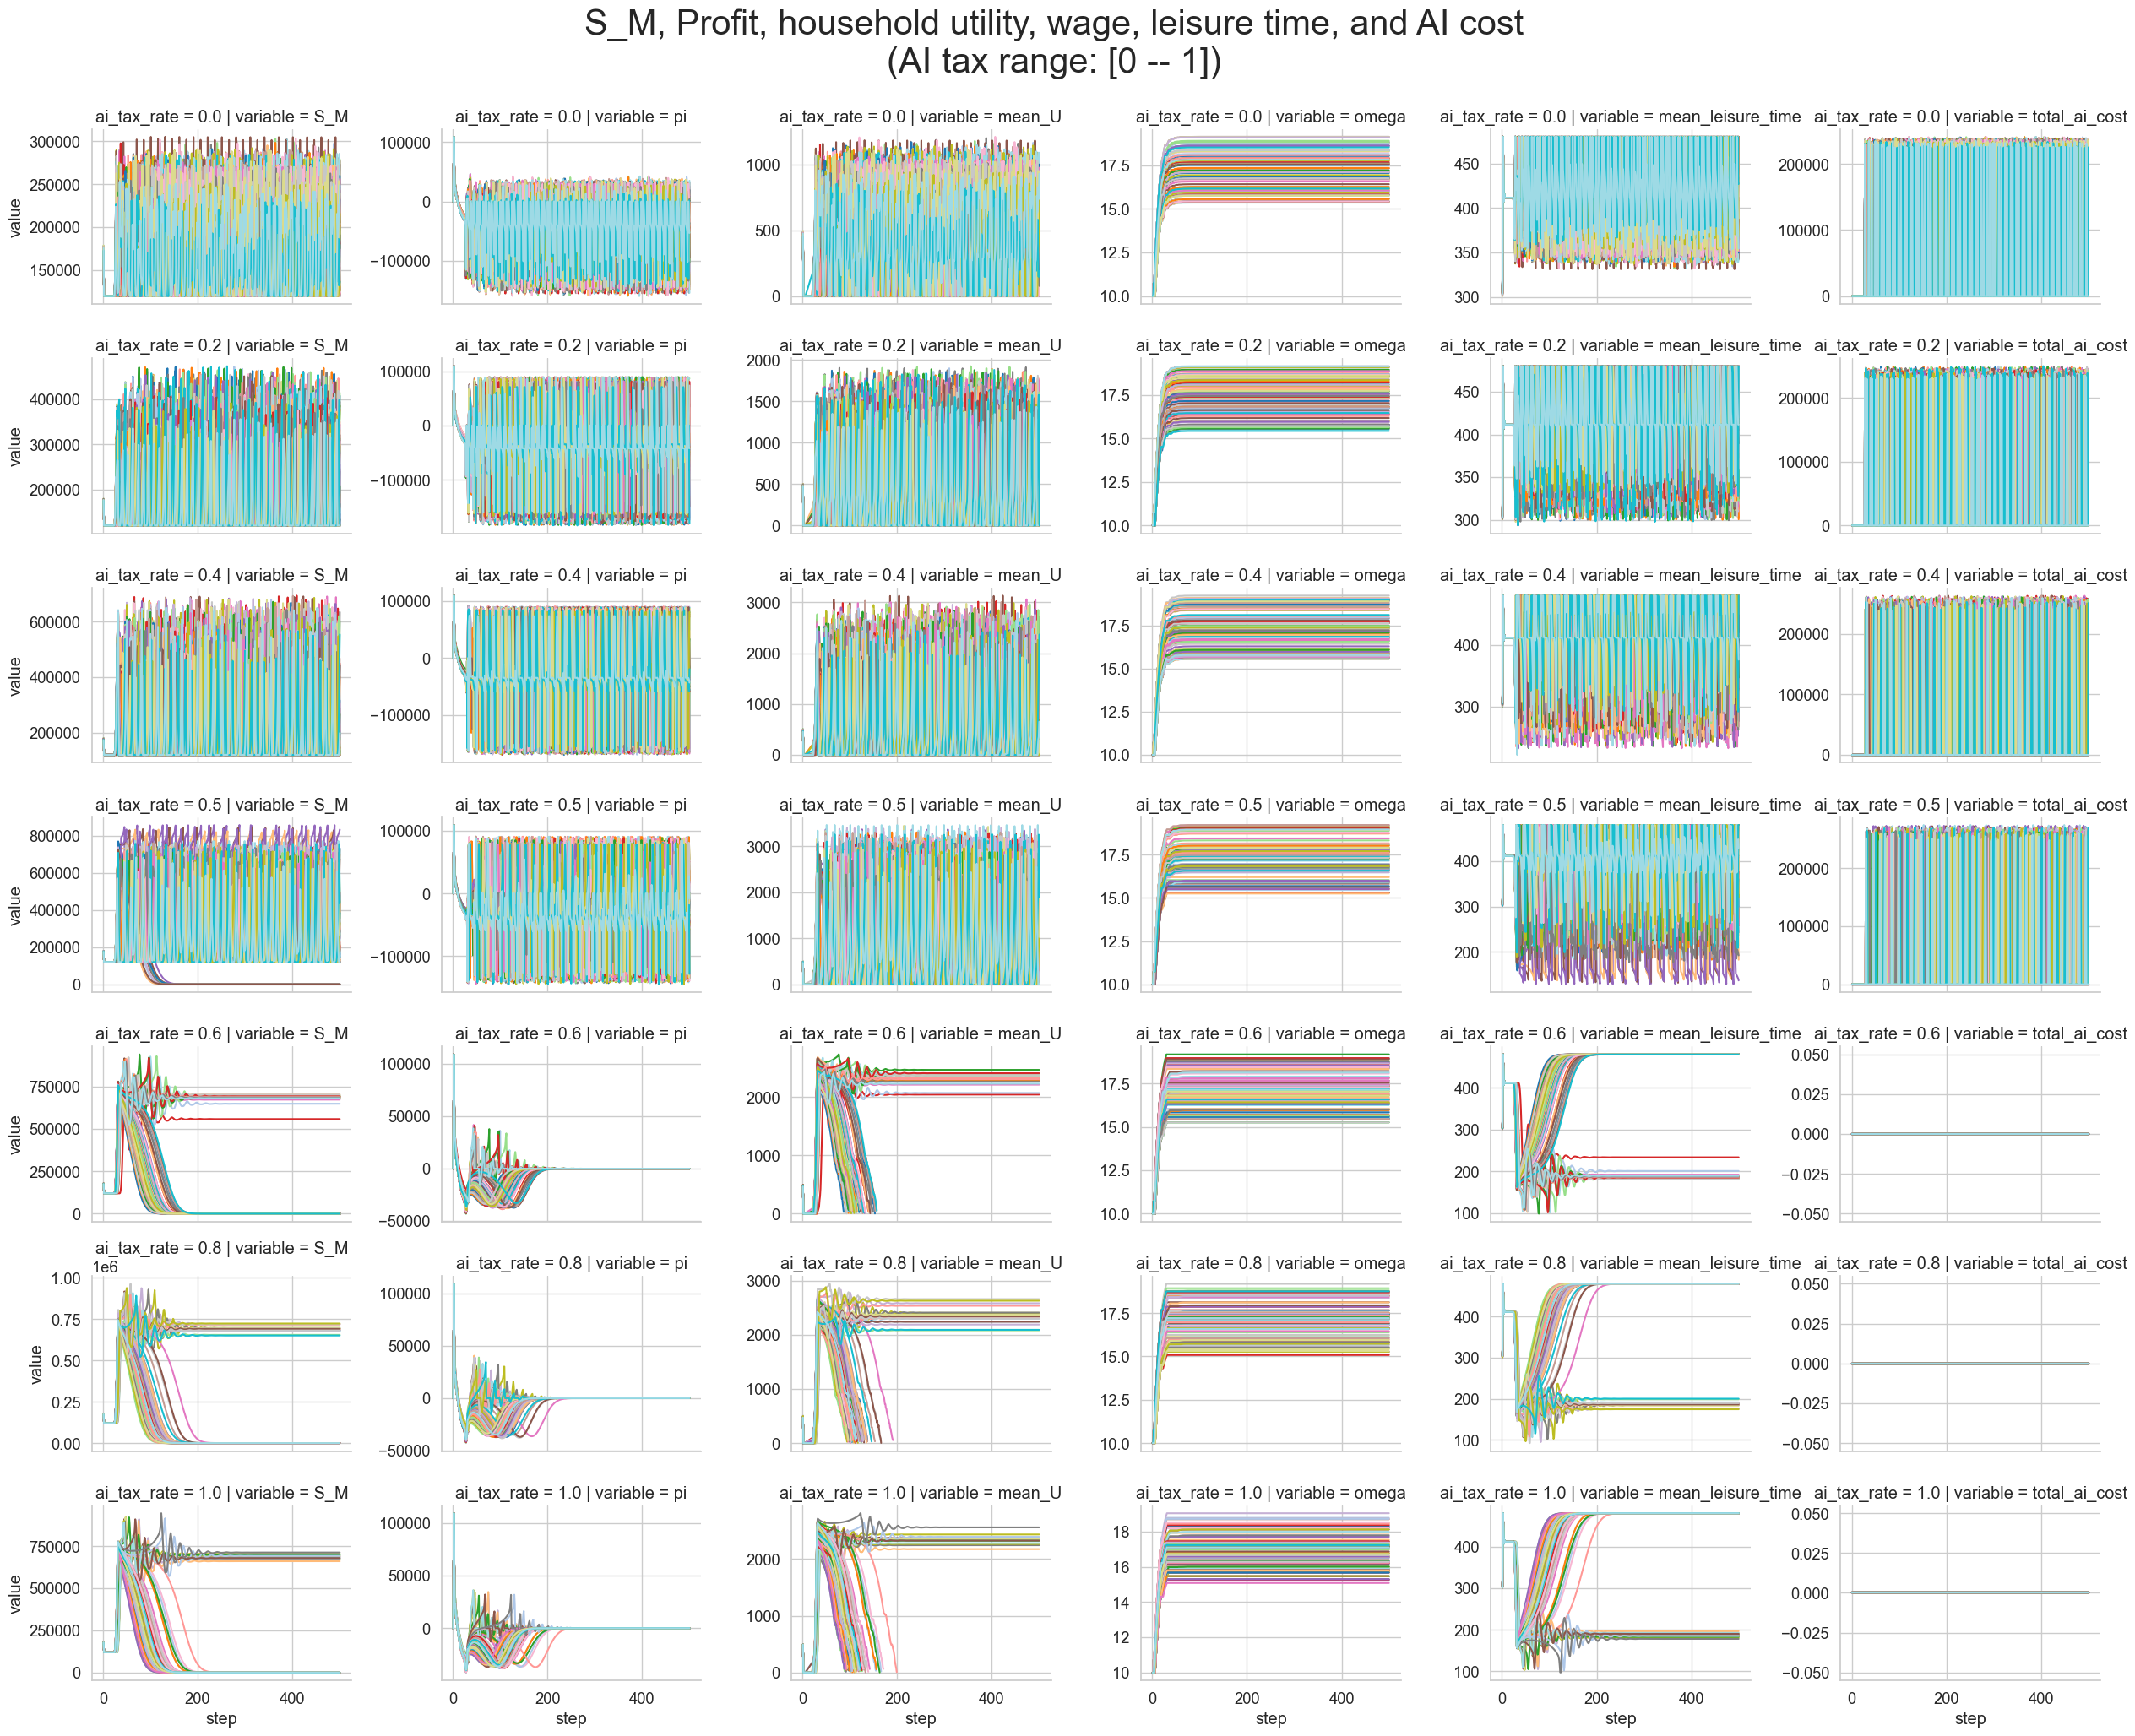

In [4]:
sns.set_theme(style='whitegrid', font_scale=1.2)

sns.relplot(srf.query("(step > 0) & (theta == 0.1)").melt(id_vars=['step','ai_tax_rate','run'], value_vars=['S_M','pi','mean_U','omega','mean_leisure_time','total_ai_cost']), x='step', y='value', kind='line', hue='run', col='variable', row='ai_tax_rate',palette='tab20', facet_kws={'sharey':False},legend=False, height=2.8, aspect=1.5)

plt.suptitle('S_M, Profit, household utility, wage, leisure time, and AI cost\n'
             '(AI tax range: [0 -- 1])', y=1.05, fontsize=30)

Text(0.5, 1.05, 'Single run: S_M, Profit, household utility, wage, leisure time, and AI cost\n(AI tax range: [0 -- 1])')

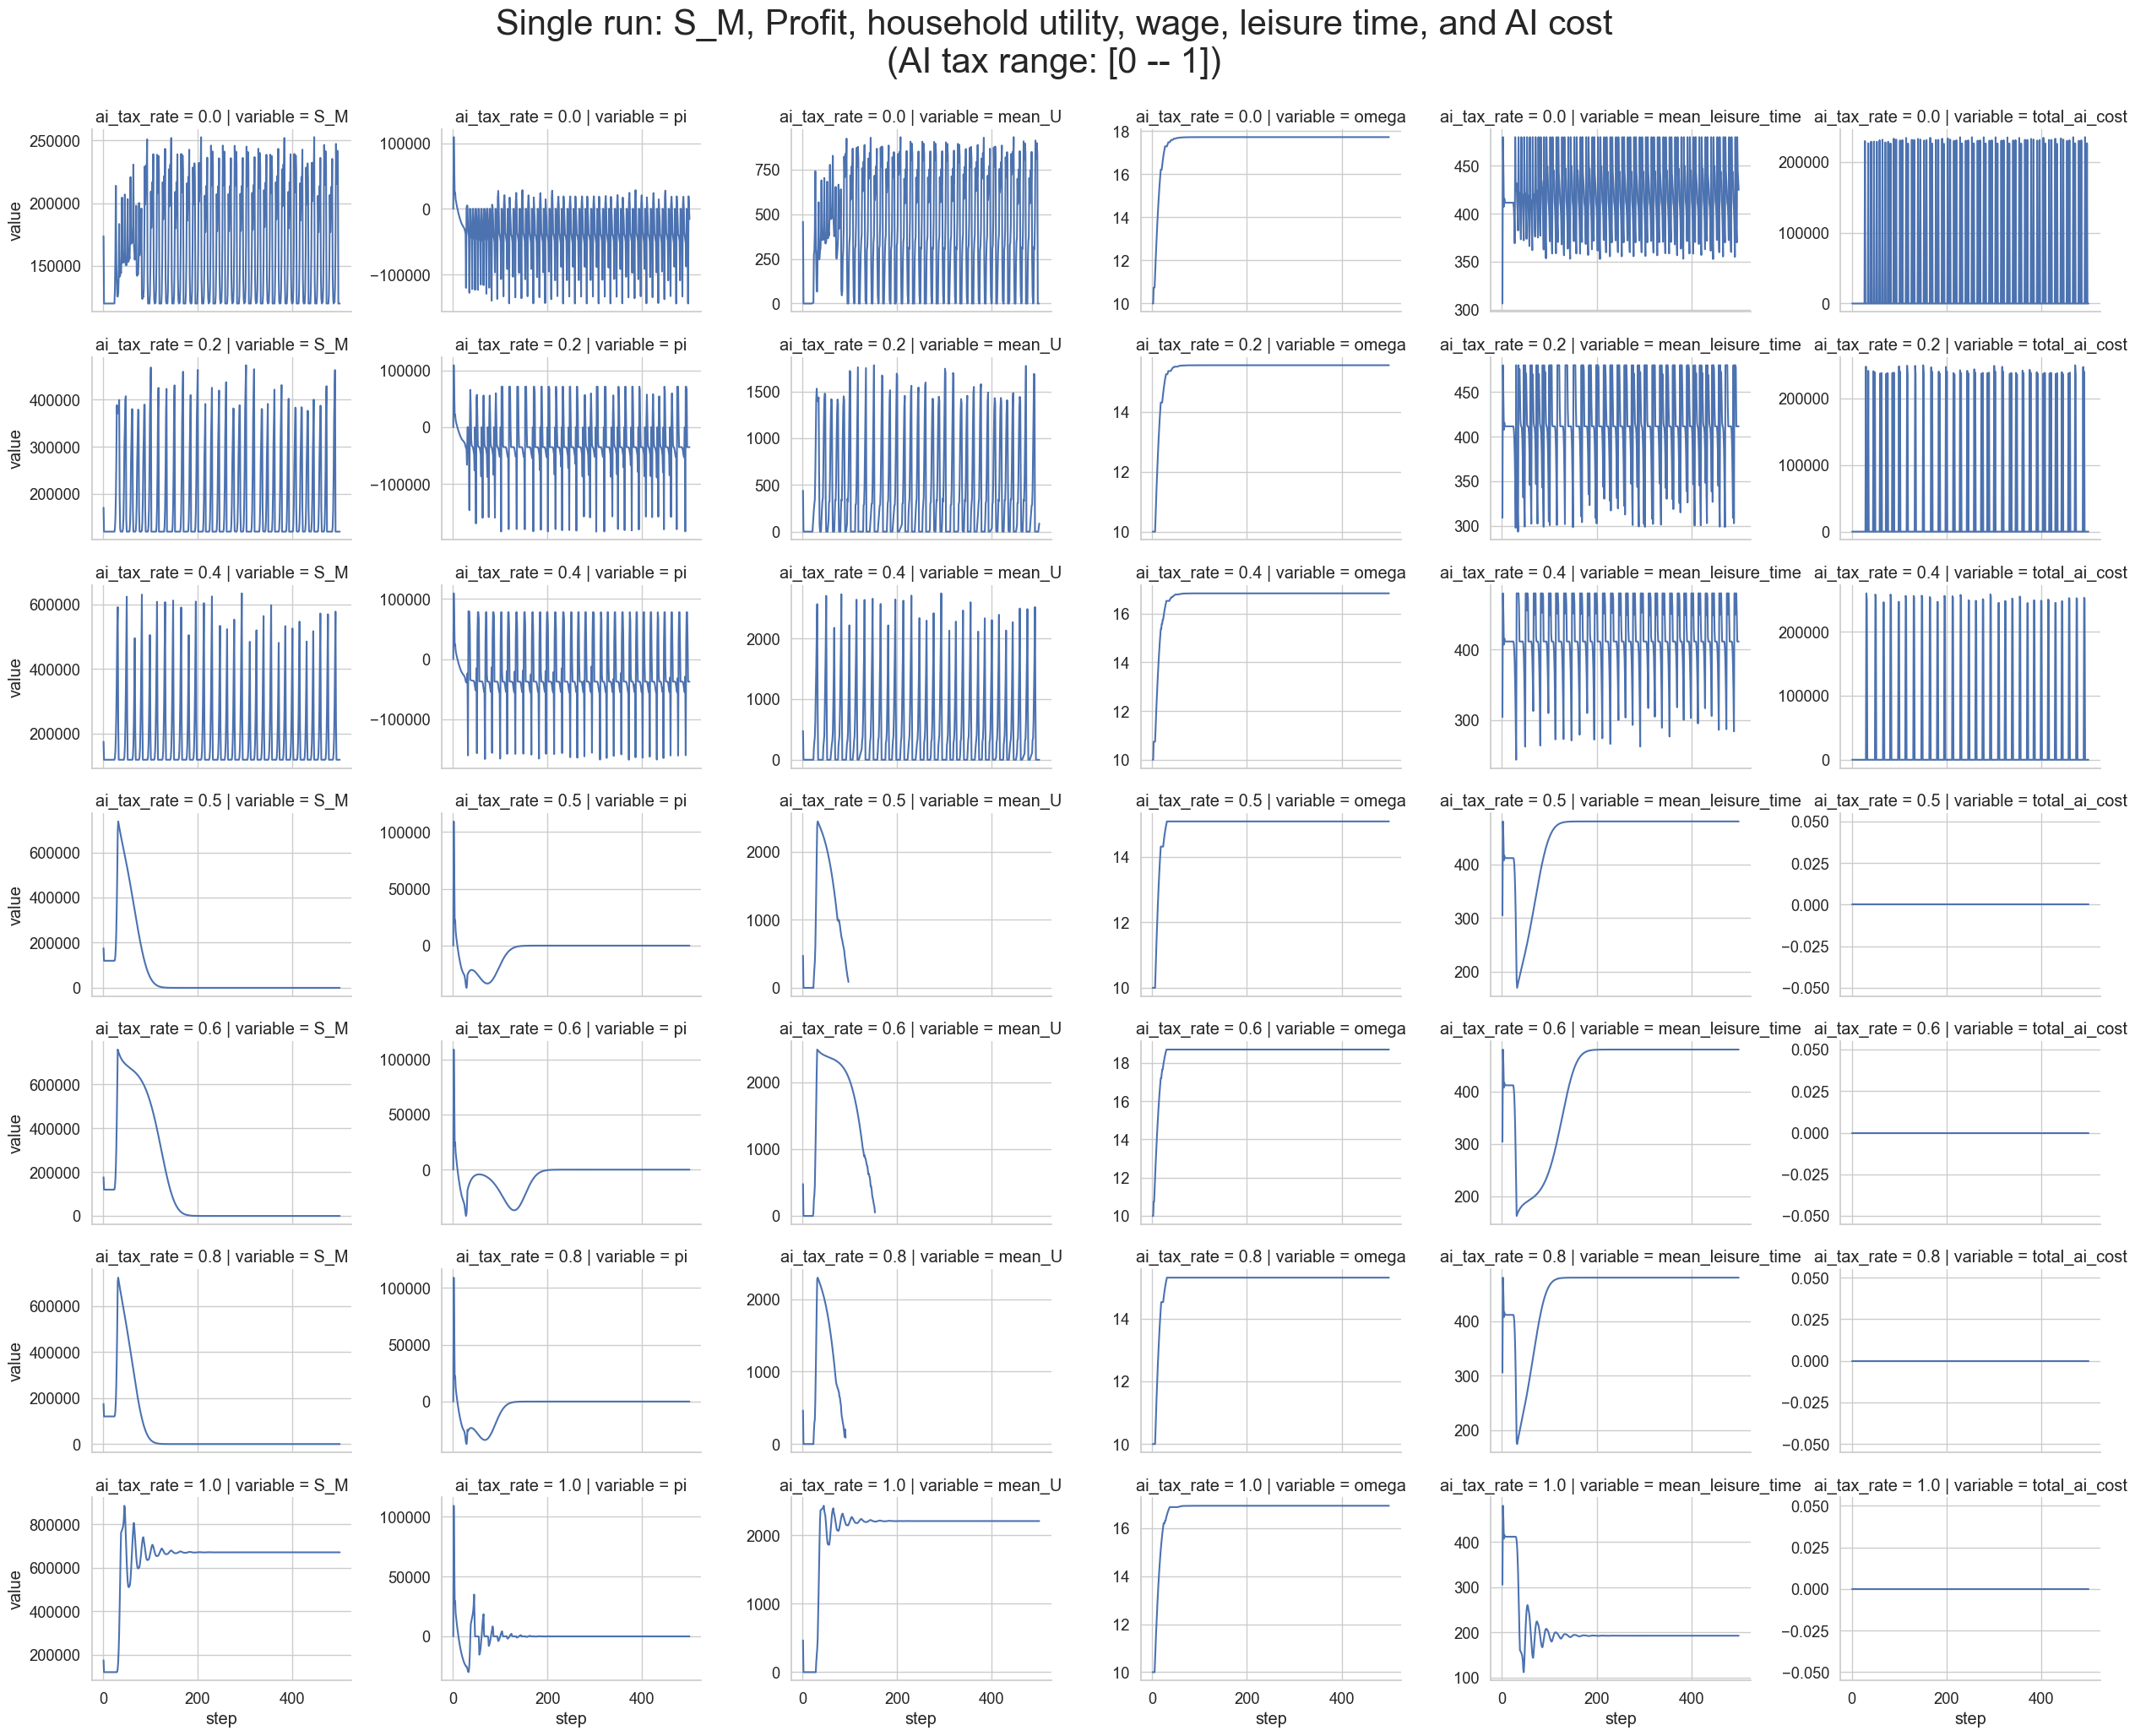

In [32]:
sns.set_theme(style='whitegrid', font_scale=1.2)

random_run_number = np.random.randint(0, srf['run'].max()) 

sns.relplot(srf.query("(step > 0) & (theta == 0.1) & (run == @random_run_number)").melt(id_vars=['step','ai_tax_rate','run'], value_vars=['S_M','pi','mean_U','omega','mean_leisure_time','total_ai_cost']), x='step', y='value', kind='line', col='variable', row='ai_tax_rate',palette='tab20', facet_kws={'sharey':False},legend=False, height=2.8, aspect=1.5)

plt.suptitle('Single run: S_M, Profit, household utility, wage, leisure time, and AI cost\n'
             '(AI tax range: [0 -- 1])', y=1.05, fontsize=30)

### Insight
When fixed AI cost is $200,000 and variable cost is $2 per human-equivalent-hour, AI tax between 0.5-0.6 show two pathways.
So, I run it again between 0.5-0.6

In [13]:
params = {'fix_ai_cost_list':(200_000,), 'ai_omega_list':(2,), 'ai_tax_rate_list':(.5, .52,.54,.56,.58,.6)}
srf, final_srf=run_simulation(**params)

This experiment consists of 600 simulations
consisting of 6 parameter sets.

Finished series.


Text(0.5, 1.05, 'S_M, Profit, household utility, wage, leisure time, and AI cost\n(AI tax range: [0.5 -- 0.6])')

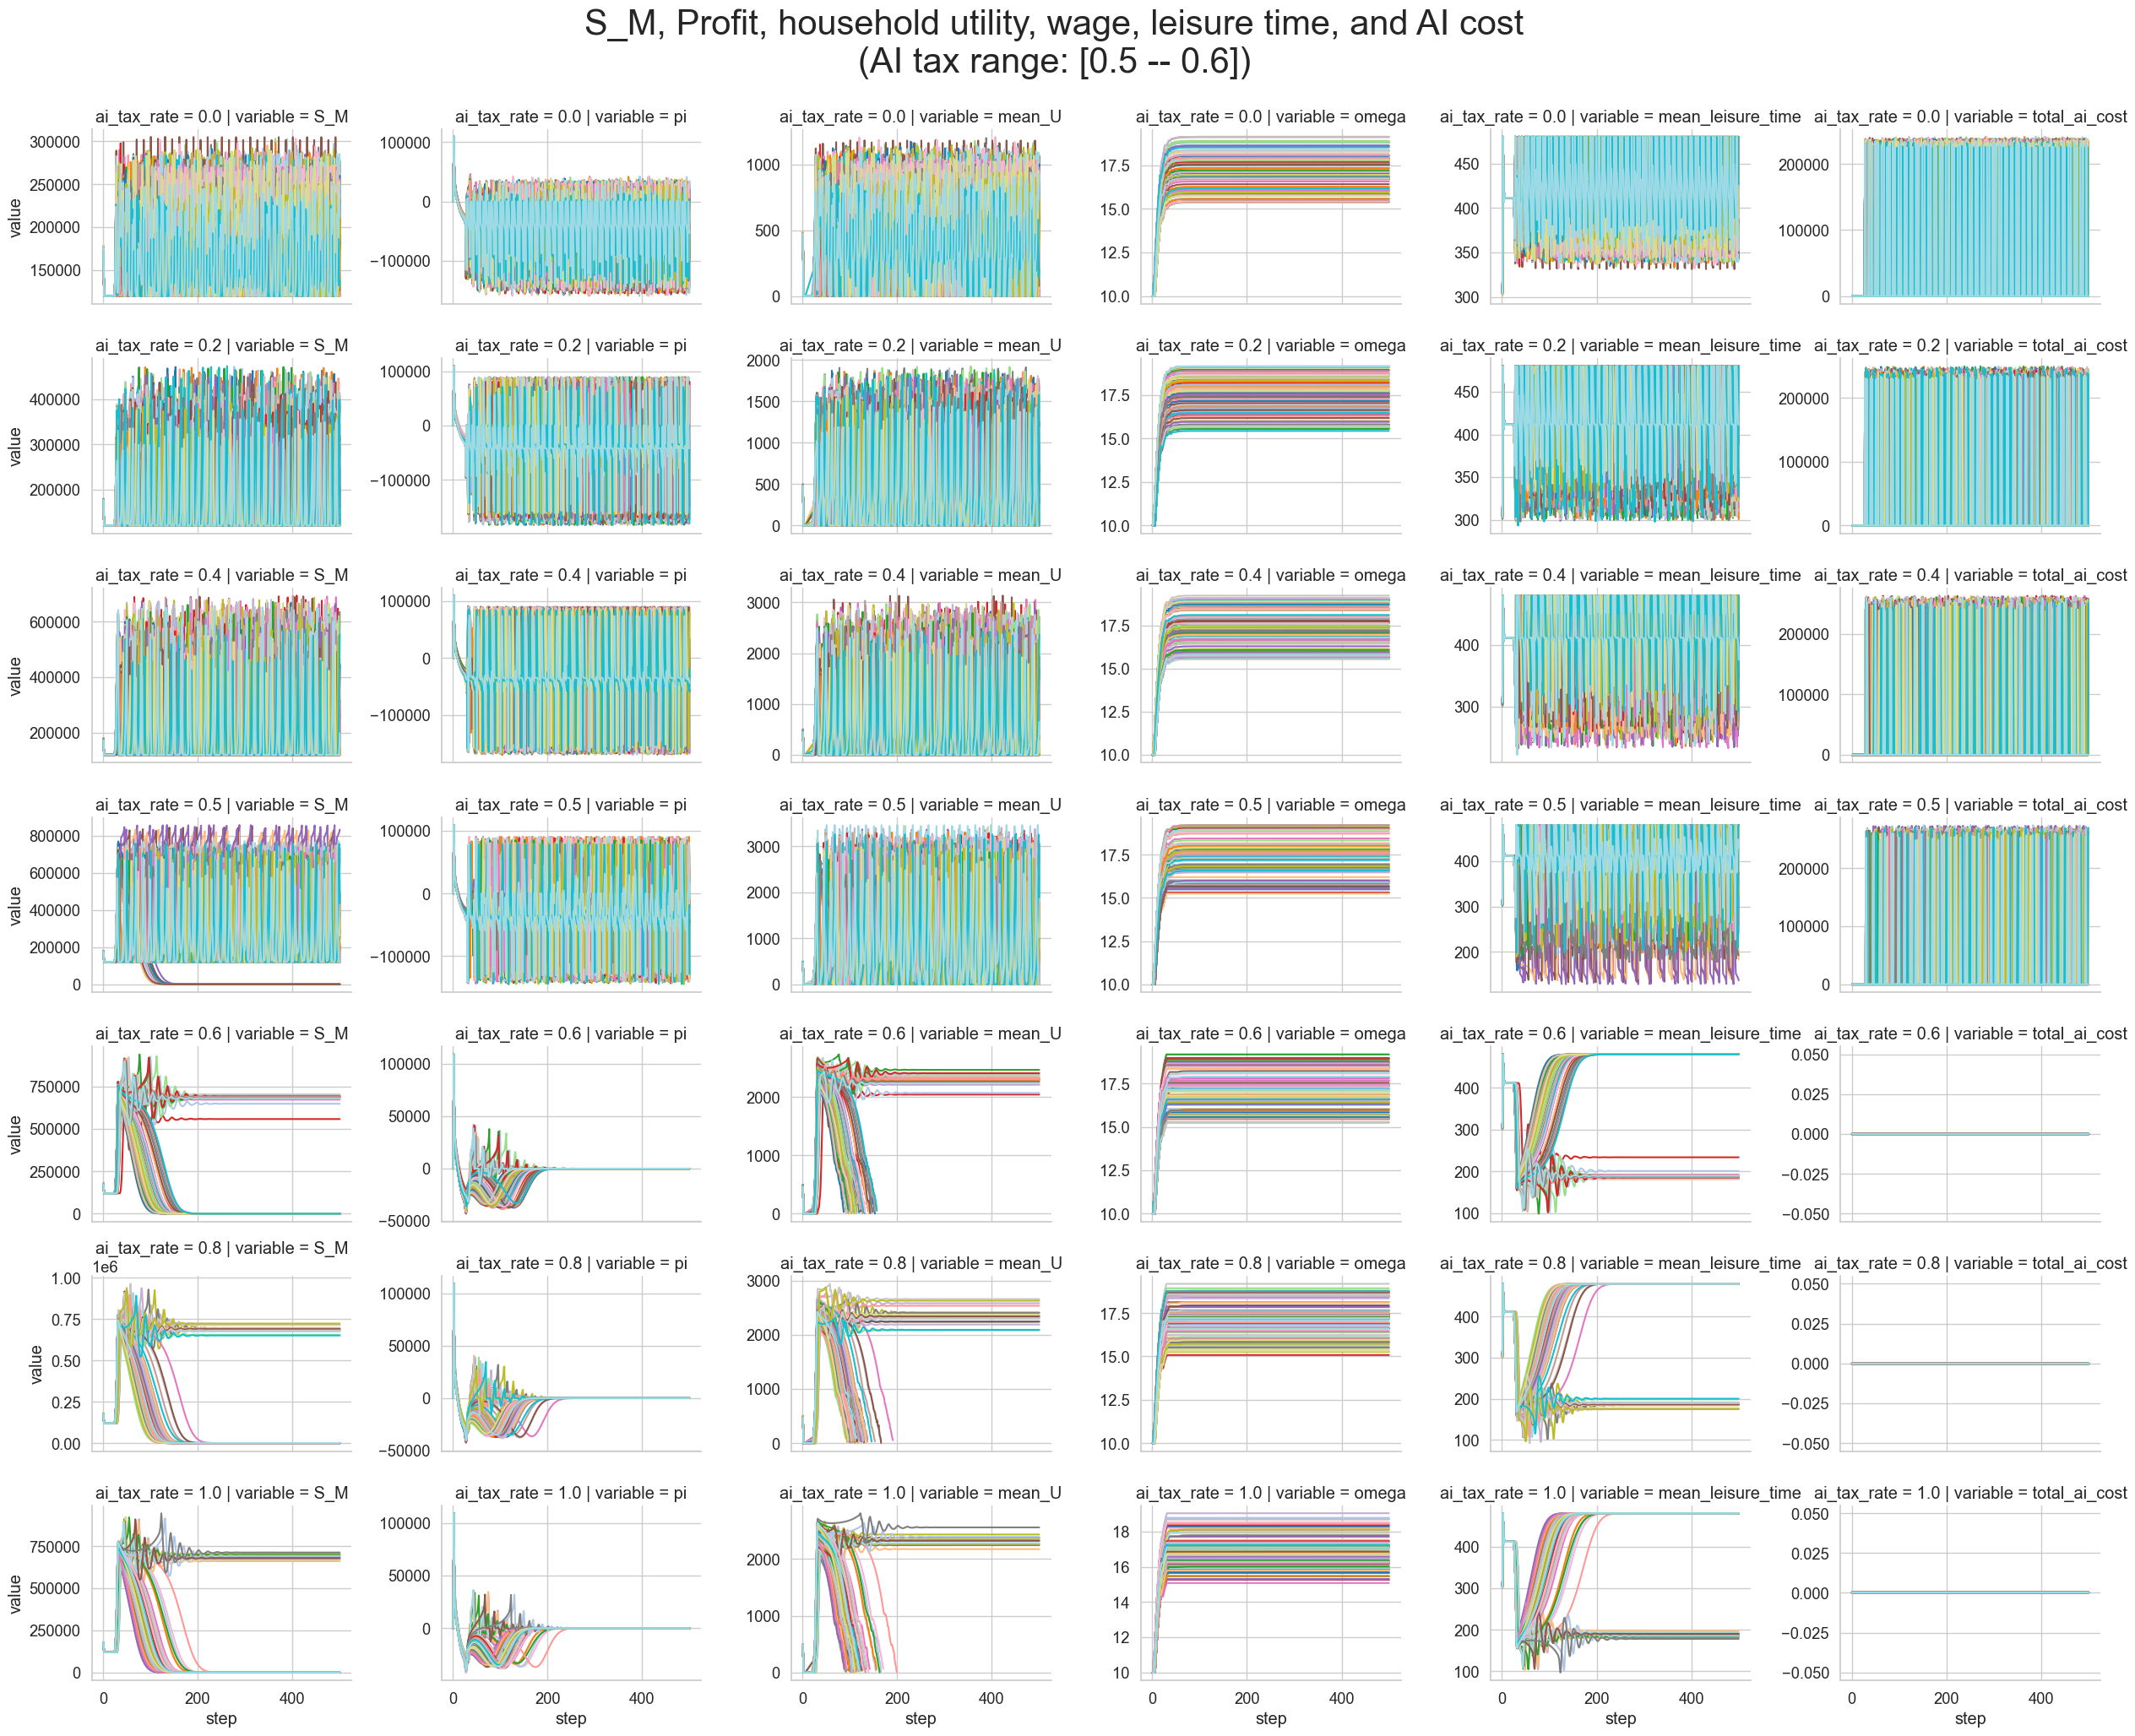

In [5]:
sns.set_theme(style='whitegrid', font_scale=1.2)

sns.relplot(srf.query("(step > 0) & (theta == 0.1)").melt(id_vars=['step','ai_tax_rate','run'], value_vars=['S_M','pi','mean_U','omega','mean_leisure_time','total_ai_cost']), x='step', y='value', kind='line', hue='run', col='variable', row='ai_tax_rate',palette='tab20', facet_kws={'sharey':False},legend=False, height=2.8, aspect=1.5)

plt.suptitle('S_M, Profit, household utility, wage, leisure time, and AI cost\n'
             '(AI tax range: [0.5 -- 0.6])', y=1.05, fontsize=30)

## Matrix scenario
If there is no AI tax

In [35]:
ai_tax_rate=(0,)

params = {'fix_ai_cost_list':(200_000,), 'ai_omega_list':(2,), 'ai_tax_rate_list':ai_tax_rate, "reps":3}
srf, final_srf=run_simulation(**params)

This experiment consists of 3 simulations
consisting of 1 parameter sets.

Finished series.


Text(0.5, 1.02, 'S_M, Profit, household utility, wage, leisure time, and AI cost\n(AI tax == 0)')

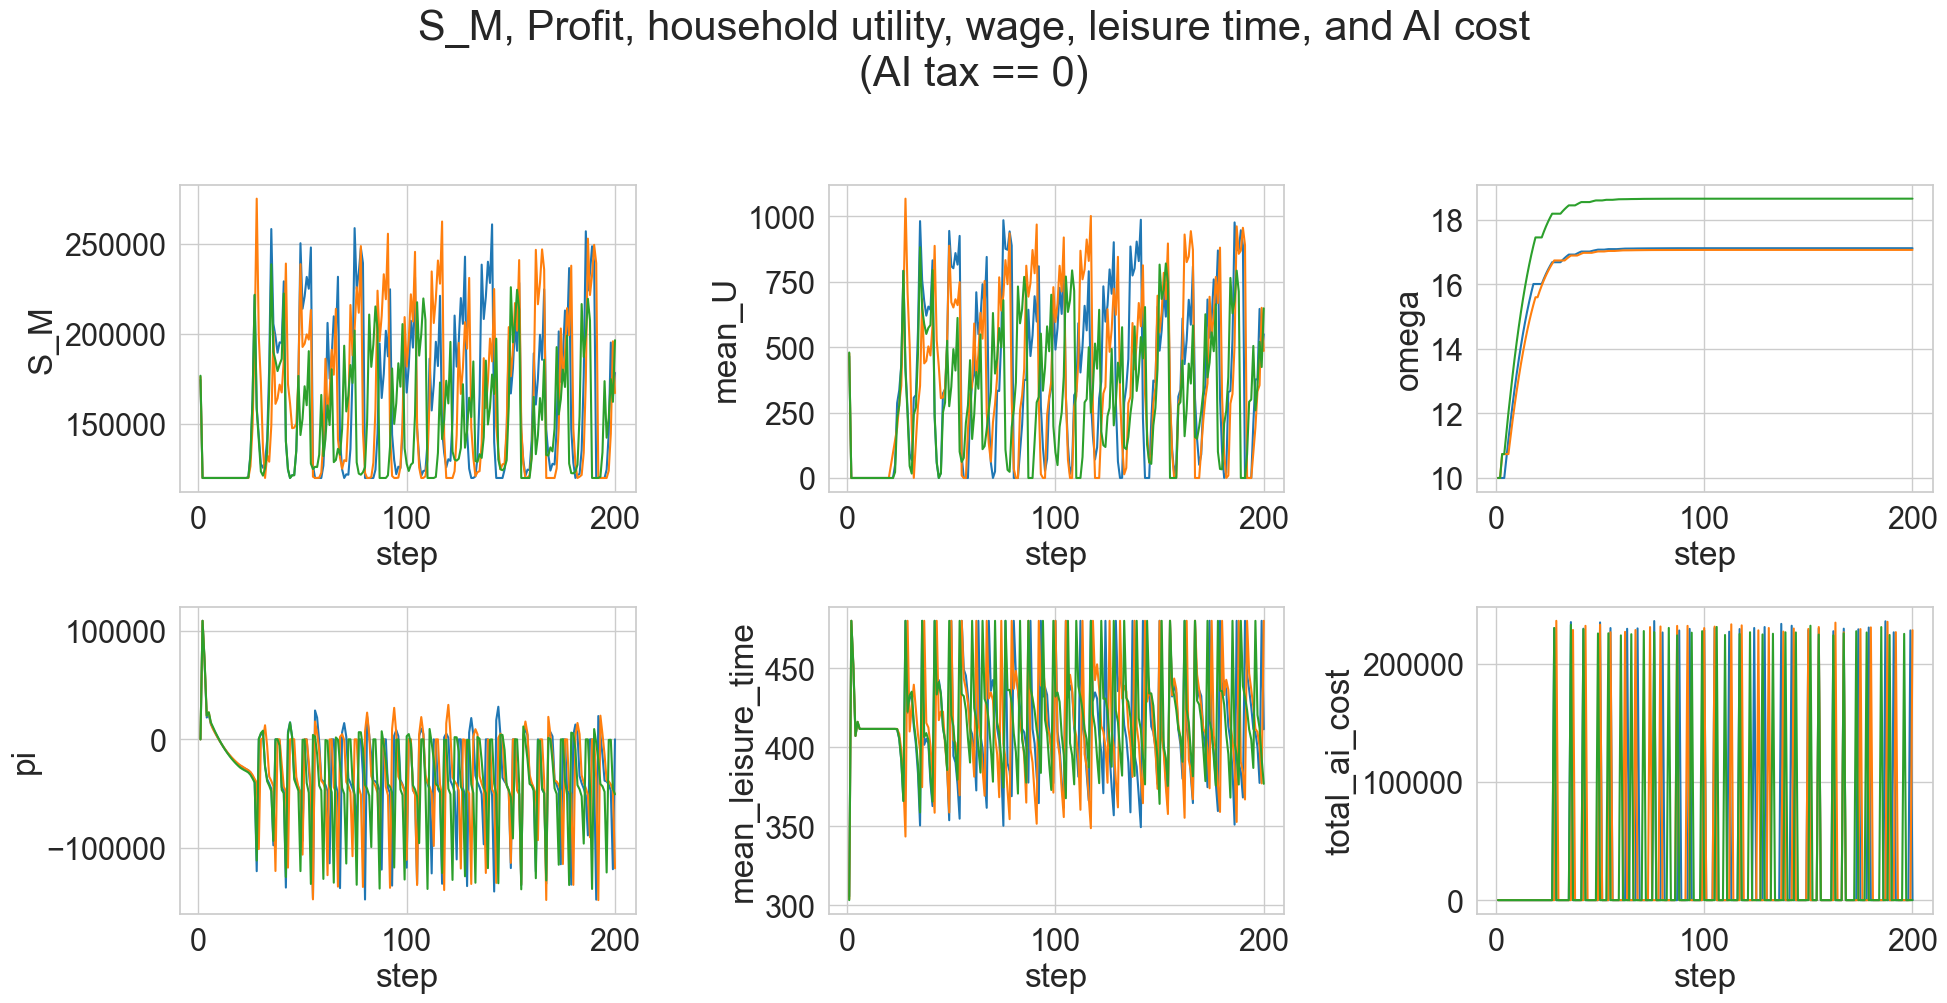

In [37]:
sns.set_theme(style='whitegrid', font_scale=2)
max_step=200

fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(20,10), sharey=False, sharex=False,tight_layout=True)
for col, ax in zip(['S_M','mean_U','omega','pi','mean_leisure_time','total_ai_cost'], axes.flat):
    sns.lineplot(data=srf.query("(step > 0) & (theta == 0.1) & (step <= @max_step)"), x='step', y=col, hue='run',ax=ax, legend=False, palette='tab10')

plt.suptitle(f'S_M, Profit, household utility, wage, leisure time, and AI cost\n'
             f'(AI tax == 0)', y=1.02, fontsize=30)

## Wall-E scenario

Leisure time = $H_max$
Utility maximized.

Failed to produce a stable scenario. 

In [21]:
params = {'fix_ai_cost_list':(200_000,), 'ai_omega_list':(2,), 'ai_tax_rate_list':(.58,), 't_max':250}
srf, final_srf=run_simulation(**params)

This experiment consists of 100 simulations
consisting of 1 parameter sets.

Finished series.


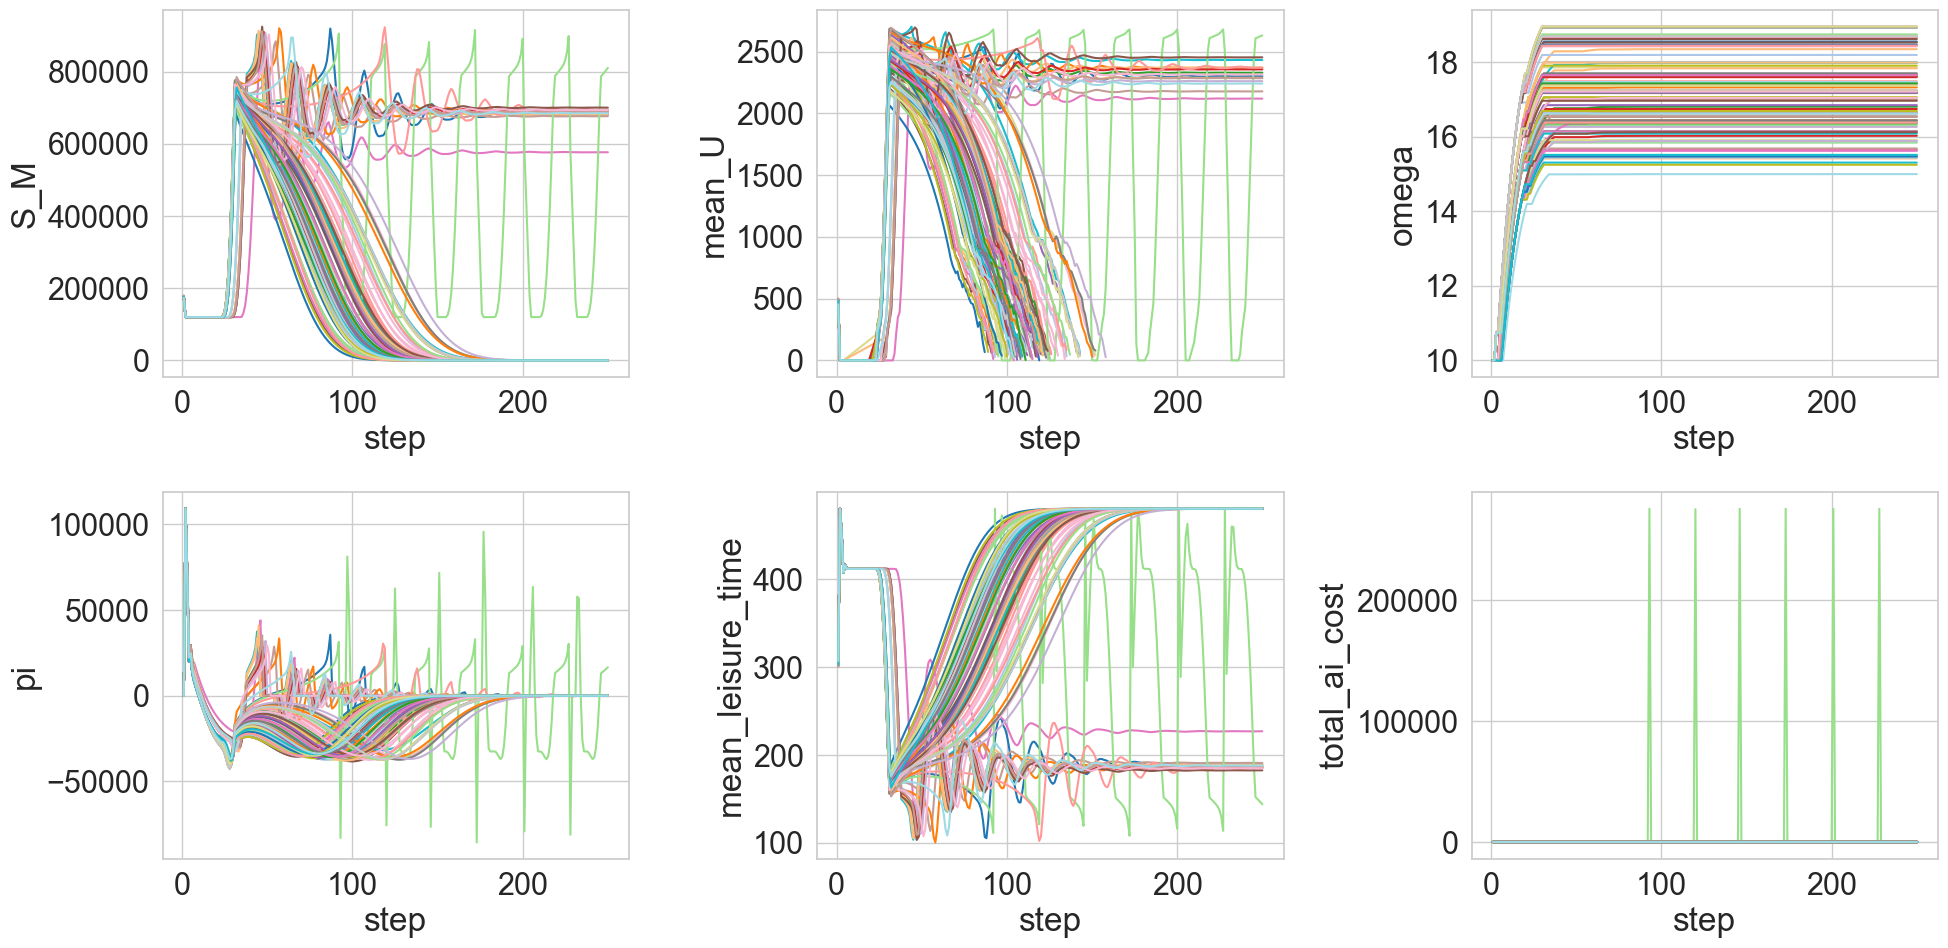

In [22]:
sns.set_theme(style='whitegrid', font_scale=2)

fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(20,10), sharey=False, sharex=False,tight_layout=True)

for col, ax in zip(['S_M','mean_U','omega','pi','mean_leisure_time','total_ai_cost'], axes.flat):
    sns.lineplot(data=srf.query("(step > 0) & (theta == 0.1)"), x='step', y=col, hue='run',
             ax=ax, legend=False, palette='tab20')

## Matrix scenario


In [2]:


#### series setup
directory, series_name, seed, reps, n_sets, series_params_list = series_params(ai_tax_rate_list=(.99,))

#### verify directory exists
from pathlib import Path
Path(directory).mkdir(parents=True, exist_ok=True)

#### initialise rng to be used by simulation series
rng = default_rng(seed)

print('This experiment consists of {} simulations'.format(n_sets * reps))
print('consisting of {} parameter sets.'.format(n_sets))

#### intitialise storage vehicle for series results
series_results = []


#### main body of multi parameter set code
for params in series_params_list:
    sim_results = simulation(*params, rng)
    series_results = series_results + sim_results

print('\nFinished series.')

macro_labels = ['set', 'run', 'step', 't_max', 'n', 'H_max', 'A', 'gamma', 'mu', 'S_N', 'omega_0', 'p_0', 'delta_0', 
                'theta', 'min_pct', 'pct_change',
                'I', 'pi', 'total_pi', 'omega', 'p', 'H_D', 'S_S', 'S_P', 'S_hat', 'N', 'H_S', 'H_M', 'S_D', 'S_M',
                'total_H_N', 'total_H_O','total_m', 'med_m', 'mean_m', 'max_m', 'min_m', 'mean_U', 'mean_alpha',
                'is_ai','mean_hours_worked','fix_cost_ai','omega_ai','ai_tax_rate',
                'total_human_hours', 'total_human_cost', 'total_ai_cost']
#### Transform list of lists into dataframes

series_results_frame = pd.DataFrame(series_results, columns = macro_labels)

#### For troubleshooting
#print(series_results_frame)

#### Save dataframe to directory as csv file.
# print('Writing to files.')
# prefix = directory + 'series_' + series_name
# series_results_frame.to_csv(prefix + '.csv', index = False)
# print('Series results written to', prefix + '.csv')


This experiment consists of 100 simulations
consisting of 1 parameter sets.

Finished series.


In [4]:
srf = series_results_frame
del(series_results_frame)
srf['mean_beta'] = 1 - srf['mean_alpha']
srf['ratio'] = srf['omega'] / srf['p']
srf['sugar_diff'] = abs(srf['S_S'] - srf['S_D'])
srf['hours_diff'] = abs(srf['S_S'] - srf['S_D'])
final_srf = srf[srf['step'] == max(srf['step'])]

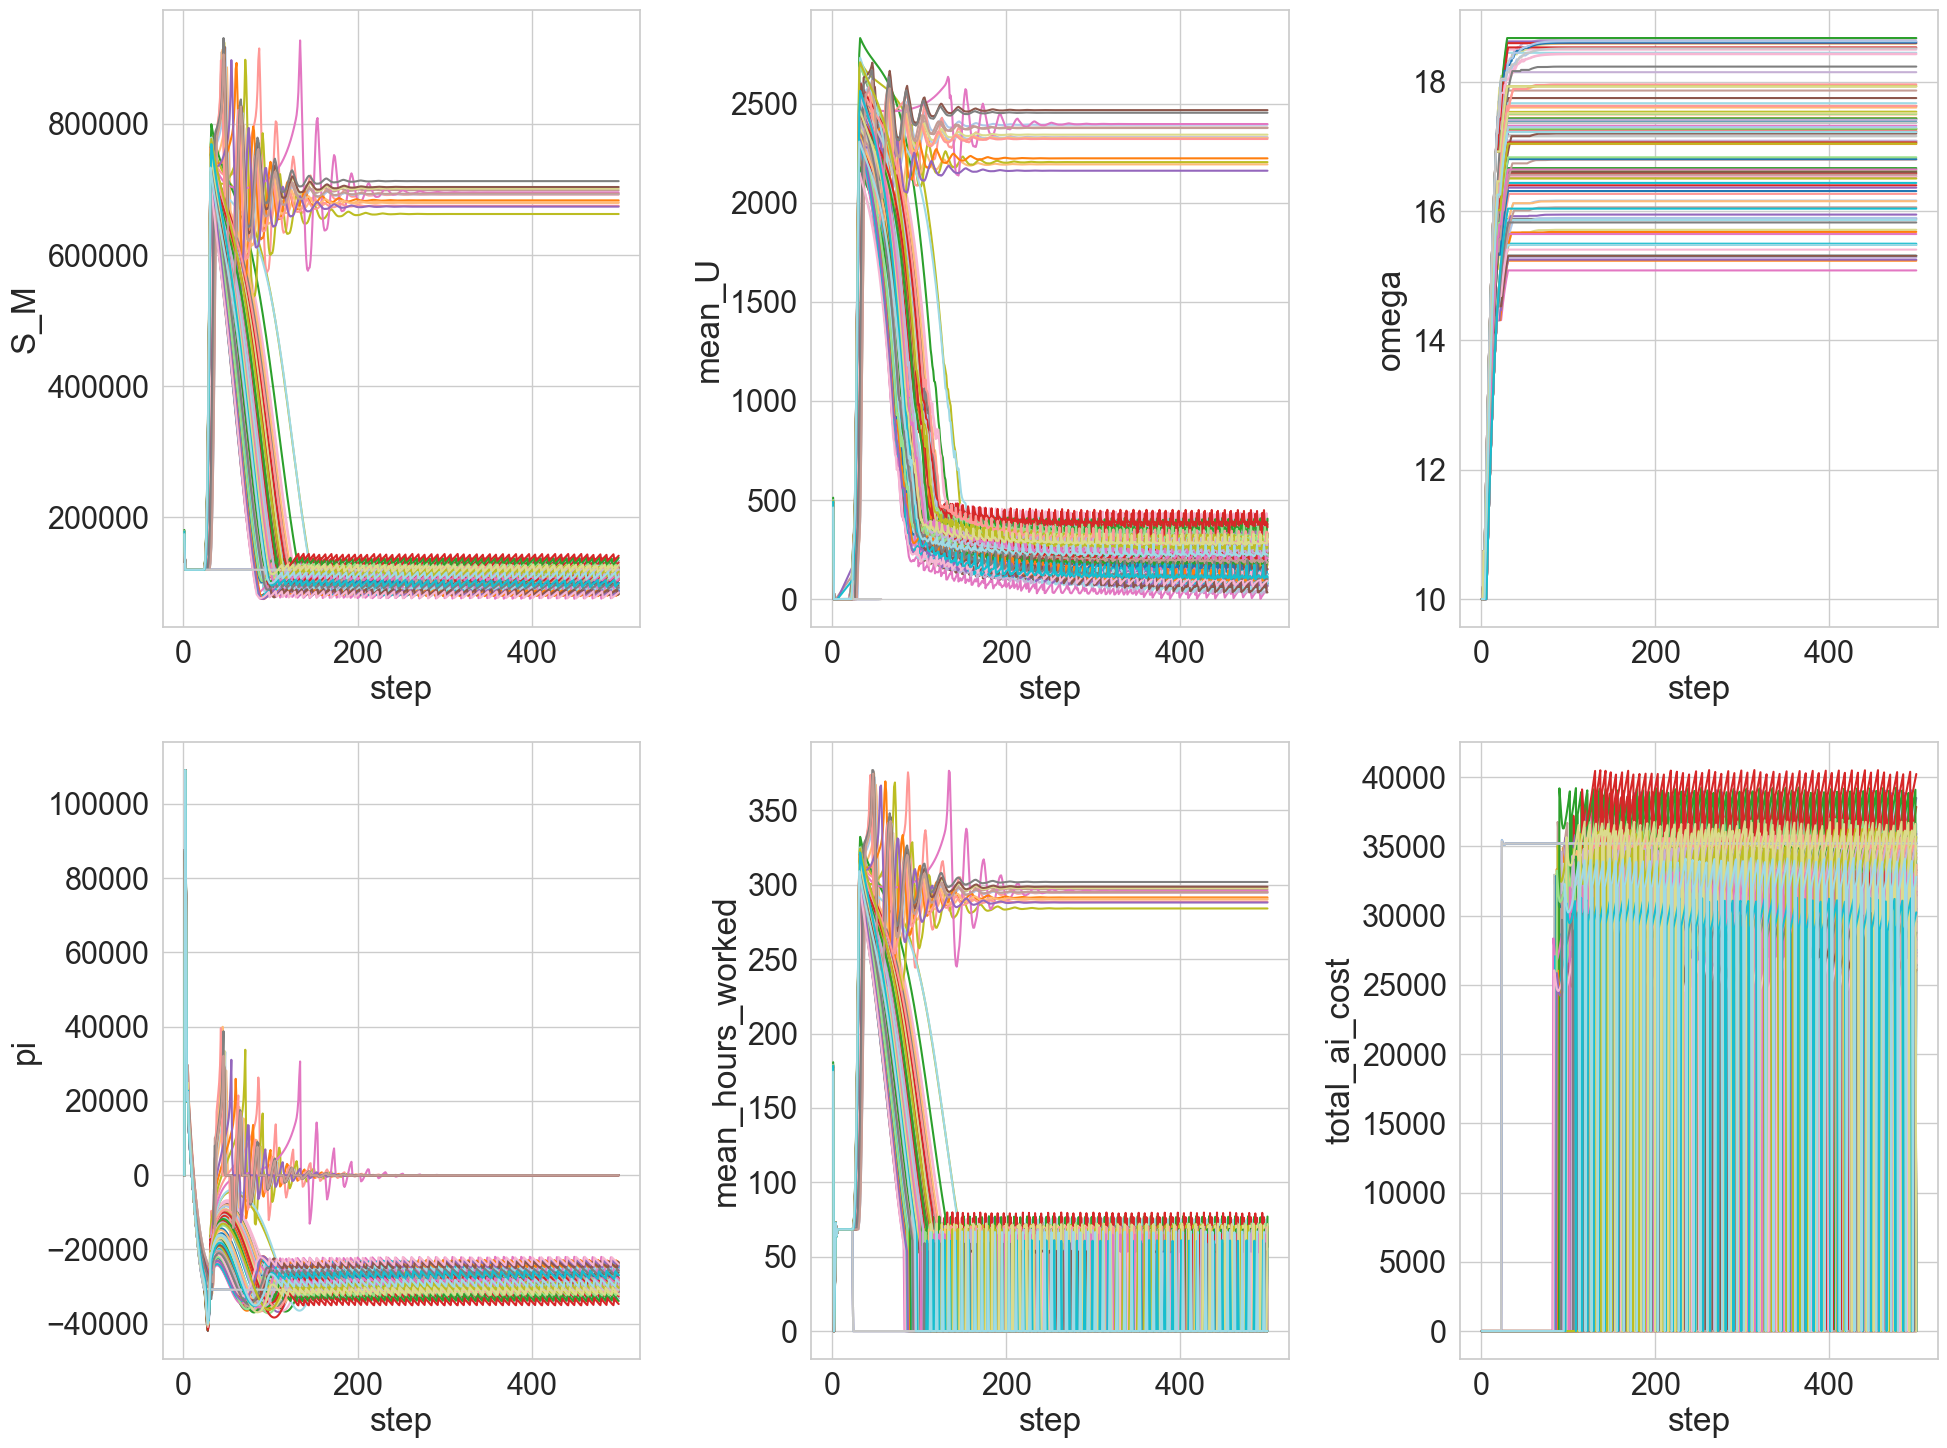

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=2)

fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(20,15), sharey=False, sharex=False,tight_layout=True)

# for col, ax in zip(['S_M','mean_U','omega','pi','mean_hours_worked','total_ai_cost'], axes.flat):
for col, ax in zip(['S_M','mean_U','omega','pi','mean_hours_worked','total_ai_cost'], axes.flat):
    sns.lineplot(data=srf.query("(step > 0) & (theta == 0.1)"), x='step', y=col, hue='run',
             ax=ax, legend=False, palette='tab20')


# plt.rc('font',**{'family':'sans-serif','sans-serif':['Futura']})

# plot_data = srf[['step', 'S_M', 'run']][srf['step'] > 0][srf['theta'] == .1]
# plot_data_wide = pd.pivot_table(plot_data, index = ['step'], values = ['S_M'], columns = ['run'])
# plot_data_wide.plot(linewidth=.5, legend=None)

# plt.ylabel('S_M')
#plt.title('Household Simulation Results')
# sns.despine(left = True, bottom = True)

In [13]:
plot_data = srf[['step', 'S_M', 'run']][srf['step'] > 0][srf['theta'] == .1]
plot_data_wide = pd.pivot_table(plot_data, index = ['step'], values = ['S_M'], columns = ['run'])
# plot_data_wide.plot(linewidth=.5, legend=None)

plot = plot_data_wide.plot()
plt.close()
colours = plot.lines
colour_list = []
for r in range(100):
    colour_list.append(colours[r].get_color())

NameError: name 'plot_data_wide' is not defined

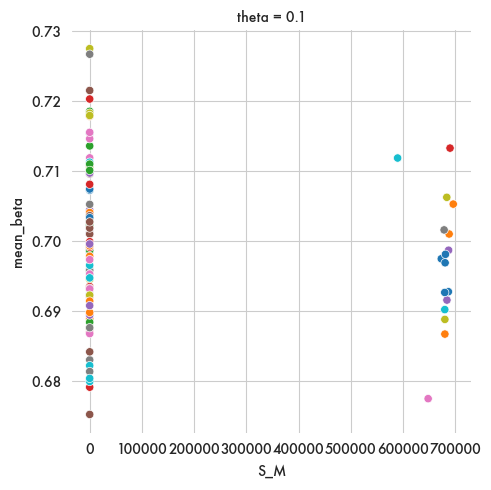

In [6]:
sns.relplot(
    data=final_srf,
    x="S_M", y="mean_beta",
    hue="run", col="theta",
    kind="scatter", 
    height=5, aspect=1, legend=None,
    palette = colour_list
)
sns.despine(left = True, bottom = True)
#plt.savefig('HoursAnnealingScanSingleHouseholdBetas.pdf')